In [7]:
exp_save_path = r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper\results\(n_train)1000__(B_RF)1000__(B_1)200__(n_sim)1000__(seed)42__4kovariates\121.90058'
patient = 'averageS'

#exp_save_path = r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper\results\(n_train)1000__(B_RF)1000__(B_1)200__(n_sim)1000__(seed)42__4kovariates_higherS(tau)\109.90058'
#patient = 'higherS'

#exp_save_path = r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper\results\(n_train)1000__(B_RF)1000__(B_1)200__(n_sim)1000__(seed)42__4kovariates_lowS(tau)\131.90058'
#patient = 'lowerS'

collage_name = 'figure4_morris_low_S.png'

xlim1 =  [-999 , 0.05]
xlim2 =  [-999 , 0.05]
xlim3 = [-999 , 0.05]

In [8]:
import pandas as pd
import json
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os

# erstelle verzeichnis, falls nicht vorhanden /help_figures
if not os.path.exists('help_figures'):
    os.makedirs('help_figures')

with open(exp_save_path + '/setting.json') as f:
    exp_settings = json.load(f)
S_t = exp_settings["true_survival_probability[1,3,5]"]

# lade results
results1 = pd.read_csv(exp_save_path + f"/results1__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][0]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][0]}.csv")
results3 = pd.read_csv(exp_save_path + f"/results3__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][1]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][1]}.csv")
results5 = pd.read_csv(exp_save_path + f"/results5__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][2]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][2]}.csv")
x_pred = exp_settings['X_pred_point']

#### plot corrs

<Figure size 1000x1000 with 0 Axes>

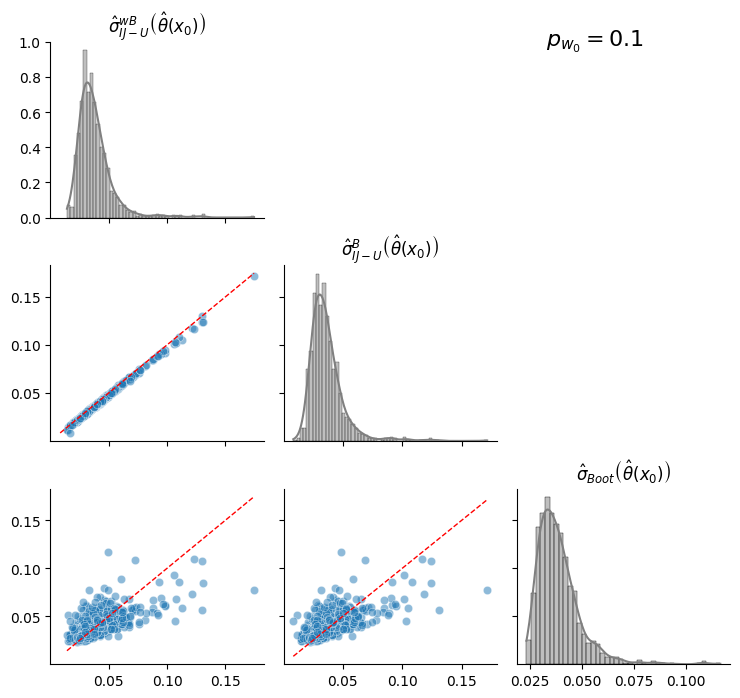

<Figure size 1000x1000 with 0 Axes>

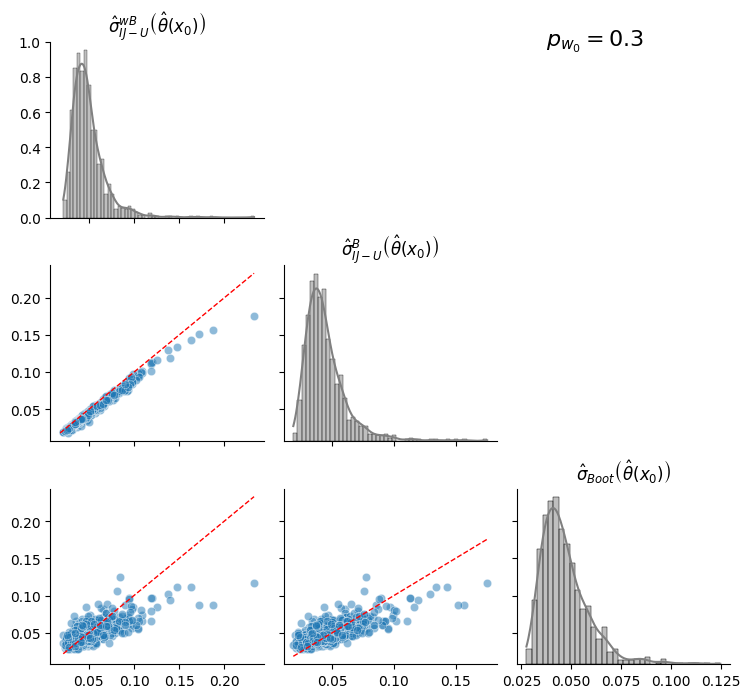

<Figure size 1000x1000 with 0 Axes>

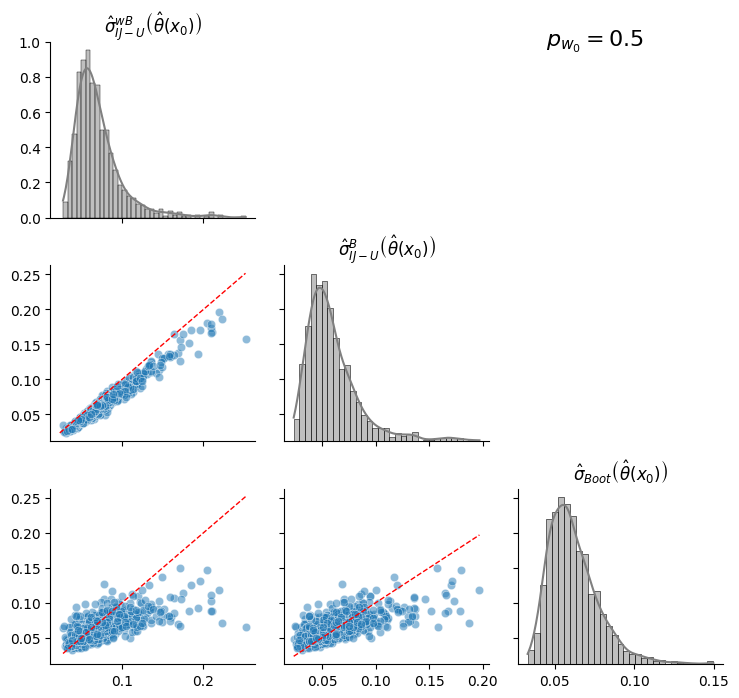

In [9]:
def plot_corr(results1, prop_weights, patient):
    boot_var  = results1['boot_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
    ijk_u_jahn = results1['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
    ijk_u_wager  = results1['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)


    if patient == 'averageS':
        df = pd.DataFrame({ r"$\hat{\sigma}_{IJ-U}^{wB} \left(\hat{\theta}(x_{0})\right)$":   ijk_u_jahn, 
                            r"$\hat{\sigma}_{IJ-U}^{B} \left(\hat{\theta}(x_{0})\right)$": ijk_u_wager, 
                             r"$\hat{\sigma}_{Boot} \left(\hat{\theta}(x_{0})\right)$":   boot_var})
    elif patient == 'higherS':
        df = pd.DataFrame({ r"$\hat{\sigma}_{IJ-U}^{wB} \left(\hat{\theta}(x_{high})\right)$":   ijk_u_jahn, 
                            r"$\hat{\sigma}_{IJ-U}^{B} \left(\hat{\theta}(x_{high})\right)$": ijk_u_wager, 
                             r"$\hat{\sigma}_{Boot} \left(\hat{\theta}(x_{high})\right)$":   boot_var})
    elif patient == 'lowerS':
        df = pd.DataFrame({ r"$\hat{\sigma}_{IJ-U}^{wB} \left(\hat{\theta}(x_{low})\right)$":   ijk_u_jahn, 
                            r"$\hat{\sigma}_{IJ-U}^{B} \left(\hat{\theta}(x_{low})\right)$": ijk_u_wager, 
                             r"$\hat{\sigma}_{Boot} \left(\hat{\theta}(x_{low})\right)$":   boot_var})
    # Bildgröße einstellen
    plt.figure(figsize=(10, 10))  # Ändere (12, 12) auf die gewünschte Breite und Höhe

    # PairGrid aufsetzen
    g = sns.PairGrid(df, diag_sharey=False)
    g.map_lower(sns.scatterplot, alpha=0.5)

    # Linie x = y
    def plot_line_x_equals_y(x, y, **kwargs):
        ax = plt.gca()
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 
                color='red', linestyle='--', linewidth=1)
    g.map_lower(plot_line_x_equals_y)

    # Hauptdiagonale: Histogramm
    g.map_diag(sns.histplot, kde=True, color="gray")

    # Obere Dreiecksplots ausblenden
    for i, j in zip(*np.triu_indices_from(g.axes, 1)):
        g.axes[i, j].set_visible(False)

    # X-Label-Namen über den obersten Plots platzieren
    for i, colname in enumerate(df.columns):
        for j in range(len(df.columns)):
            if i == j:
                ax = g.axes[j, i]  # Zugriff auf die oberste Zeile
                ax.set_title(colname, fontsize=12, fontweight='bold')  # Titel über Plot
    for ax_row in g.axes:
        for ax in ax_row:
            ax.set_xlabel("")
            ax.set_ylabel("")
    # Gesamttitel

    g.fig.suptitle(r"$p_{w_0} =$"+str(prop_weights/10), x=0.8, y=0.9, fontsize=16)
    plt.tight_layout()
    plt.savefig("./help_figures/corr"+str(prop_weights)+f"{patient}.png", dpi=300)
    #plt.close()

plot_corr(results1, 1,patient)
plot_corr(results3, 3,patient)
plot_corr(results5, 5,patient)
